### EO/EC Spectrogram Examples from an Occipital Channel

#### Imports

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.signal import spectrogram

PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")
PROCESSED_ROOT = PROJECT_ROOT / "data_processed"

features_file = PROCESSED_ROOT / "features_pre_ses1.csv"
manifest_file = PROCESSED_ROOT / "manifest_pre_ses1.csv"

In [58]:
features = pd.read_csv(features_file)
manifest = pd.read_csv(manifest_file)

display(features.head())
display(manifest.head())

,participant_id,age,condition,alpha_power_8_12,fooof_alpha_cf,fooof_alpha_pw,fooof_alpha_bw,n_epochs_kept,fooof_r2,fooof_error
0,sub-001,60,EyesClosed,-10.268460,10.124218,1.674327,1.942220,91,0.958835,0.087013
1,sub-001,60,EyesOpen,-11.278344,11.232861,0.293344,3.081986,91,0.984296,0.041236
2,sub-002,67,EyesClosed,-10.221186,9.256943,1.711060,2.451334,91,0.964858,0.078536
3,sub-002,67,EyesOpen,-11.416633,8.463996,0.211487,1.000000,91,0.981021,0.053521
4,sub-003,44,EyesClosed,-10.992970,11.359863,1.384598,1.743643,108,0.967652,0.067379


,participant_id,age,eyes_closed_file,eyes_open_file
0,sub-001,60,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
1,sub-002,67,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
2,sub-003,44,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
3,sub-004,24,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...
4,sub-005,48,C:\Users\maria\Desktop\EEG-special-course\data...,C:\Users\maria\Desktop\EEG-special-course\data...


In [59]:
alpha_wide = (
    features
    .pivot_table(
        index="participant_id",
        columns="condition",
        values="alpha_power_8_12"
    )
    .reset_index()
)

alpha_wide["alpha_diff_ec_minus_eo"] = (
    alpha_wide["EyesClosed"] - alpha_wide["EyesOpen"]
)

alpha_wide = alpha_wide.dropna(subset=["EyesClosed", "EyesOpen"]).copy()
alpha_wide = alpha_wide.sort_values("alpha_diff_ec_minus_eo", ascending=False)

display(alpha_wide.head(10))
display(alpha_wide.tail(10))

condition,participant_id,EyesClosed,EyesOpen,alpha_diff_ec_minus_eo
101,sub-102,-10.039994,-11.795987,1.755994
358,sub-359,-9.841349,-11.568847,1.727498
372,sub-373,-9.807822,-11.530944,1.723122
397,sub-398,-10.035502,-11.657786,1.622284
463,sub-464,-10.094956,-11.689475,1.594519
534,sub-535,-9.788684,-11.323411,1.534727
239,sub-240,-9.892149,-11.422435,1.530286
147,sub-148,-9.546910,-11.027433,1.480523
494,sub-495,-10.014982,-11.427767,1.412785
3,sub-004,-9.989071,-11.383964,1.394893


condition,participant_id,EyesClosed,EyesOpen,alpha_diff_ec_minus_eo
202,sub-203,-11.840117,-11.591567,-0.248550
478,sub-479,-11.734568,-11.484718,-0.249850
367,sub-368,-11.869278,-11.613235,-0.256043
8,sub-009,-10.644805,-10.386693,-0.258112
68,sub-069,-11.952282,-11.684233,-0.268049
398,sub-399,-11.773572,-11.493556,-0.280017
414,sub-415,-11.951890,-11.636617,-0.315274
322,sub-323,-11.990074,-11.651691,-0.338383
483,sub-484,-12.027691,-11.652130,-0.375560
151,sub-152,-11.071009,-10.682116,-0.388893


In [60]:
# Keep only participants with the expected direction:
# EyesClosed alpha > EyesOpen alpha
alpha_positive = alpha_wide[alpha_wide["alpha_diff_ec_minus_eo"] > 0].copy()

# Strongest EC > EO alpha effect
participant_large = alpha_positive.iloc[0]["participant_id"]

# Candidate small/moderate examples:
# avoid the absolute smallest values, because they are often noisy
candidate_small = alpha_positive.iloc[-30:-10].copy()

print("Large-effect subject:", participant_large)

print("\nCandidate small/moderate subjects:")
display(
    candidate_small[
        ["participant_id", "EyesClosed", "EyesOpen", "alpha_diff_ec_minus_eo"]
    ]
)

Large-effect subject: sub-102

Candidate small/moderate subjects:


condition,participant_id,EyesClosed,EyesOpen,alpha_diff_ec_minus_eo
123,sub-124,-11.722766,-11.818894,0.096127
99,sub-100,-11.564407,-11.660480,0.096073
56,sub-057,-11.452677,-11.547192,0.094515
315,sub-316,-11.681532,-11.770239,0.088707
533,sub-534,-11.881229,-11.966023,0.084794
601,sub-602,-11.350576,-11.430029,0.079453
454,sub-455,-11.638831,-11.711004,0.072172
411,sub-412,-11.840225,-11.909308,0.069083
426,sub-427,-11.289241,-11.358205,0.068964
376,sub-377,-11.693590,-11.758106,0.064515


In [61]:
def get_subject_files(participant_id):
    row = manifest.loc[manifest["participant_id"] == participant_id].iloc[0]
    return row["eyes_closed_file"], row["eyes_open_file"]

In [62]:
def load_oz_signal(edf_path, channel="Oz"):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    raw.pick("eeg")

    raw.resample(250, npad="auto")
    raw.filter(1.0, 40.0, verbose="ERROR")
    raw.notch_filter(freqs=[50.0], verbose="ERROR")
    raw.set_eeg_reference("average", verbose="ERROR")

    if channel not in raw.ch_names:
        raise ValueError(f"{channel} not found. Available channels: {raw.ch_names}")

    raw.pick([channel])

    signal = raw.get_data()[0]
    sfreq = raw.info["sfreq"]

    return signal, sfreq

In [75]:
def load_raw_channel(edf_path, channel="Oz"):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    raw.pick("eeg")

    raw.resample(250, npad="auto")
    raw.filter(1.0, 40.0, verbose="ERROR")
    raw.notch_filter(freqs=[50.0], verbose="ERROR")
    raw.set_eeg_reference("average", verbose="ERROR")

    if channel not in raw.ch_names:
        raise ValueError(f"{channel} not found. Available channels: {raw.ch_names}")

    raw.pick([channel])
    return raw

def compute_mne_tfr(raw, freqs=np.arange(4, 20.5, 0.5), epoch_length=4.0):
    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=epoch_length,
        overlap=0.0,
        preload=True,
        verbose="ERROR"
    )

    power = epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=3,
        picks=[0],
        average=True,
        return_itc=False,
        verbose="ERROR"
    )

    return power


In [80]:
def plot_ec_eo_mne_simple(participant_id, channel="Oz"):
    ec_file, eo_file = get_subject_files(participant_id)

    raw_ec = load_raw_channel(ec_file, channel=channel)
    raw_eo = load_raw_channel(eo_file, channel=channel)

    power_ec = compute_mne_tfr(raw_ec)
    power_eo = compute_mne_tfr(raw_eo)

    # Same color limits for EC and EO
    vmin = min(power_ec.data.min(), power_eo.data.min())
    vmax = max(power_ec.data.max(), power_eo.data.max())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    power_ec.plot(
        picks=[channel],
        axes=axes[0],
        show=False,
        colorbar=False,
        vlim=(vmin, vmax)
    )
    axes[0].set_title(f"{participant_id} - EyesClosed")

    power_eo.plot(
        picks=[channel],
        axes=axes[1],
        show=False,
        colorbar=True,
        vlim=(vmin, vmax)
    )
    axes[1].set_title(f"{participant_id} - EyesOpen")

    fig.suptitle(f"EO/EC spectrogram at {channel}", fontsize=14)
    plt.show()

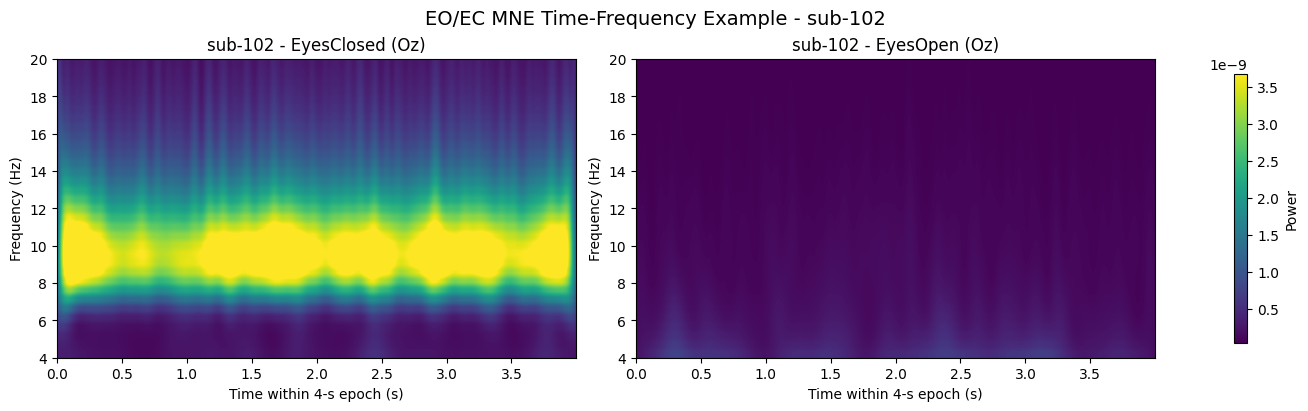

(<Average Power Estimates from Epochs (nave=47), morlet method | 1 channels × 33 freqs × 1000 times, 4.0 - 20.0 Hz, 0.00 - 4.00 s, 264 KiB>,
 <Average Power Estimates from Epochs (nave=48), morlet method | 1 channels × 33 freqs × 1000 times, 4.0 - 20.0 Hz, 0.00 - 4.00 s, 264 KiB>)

In [81]:
plot_ec_eo_mne_spectrogram(
    participant_large,
    channel="Oz",
    fmin=4,
    fmax=20
)


Candidate 1/20: sub-124


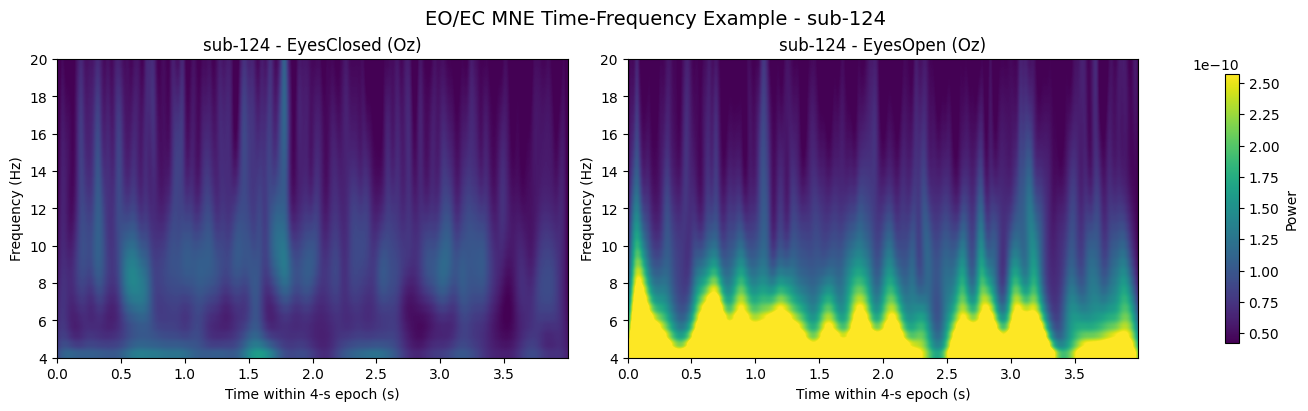


Candidate 2/20: sub-100


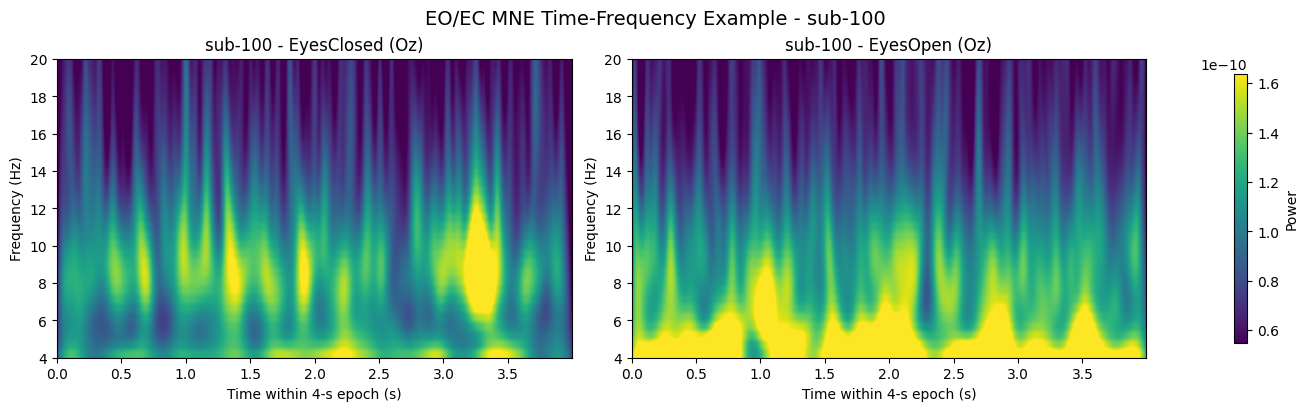


Candidate 3/20: sub-057


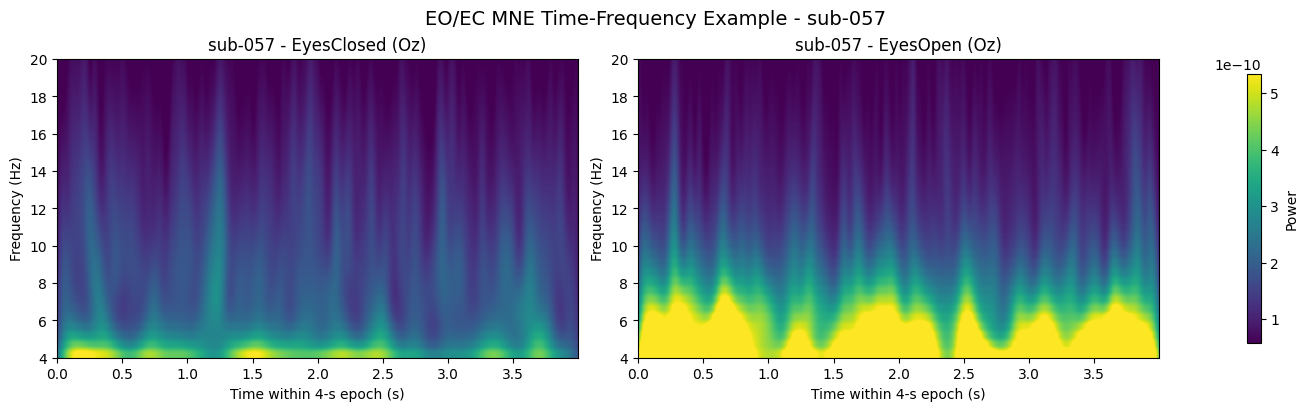


Candidate 4/20: sub-316


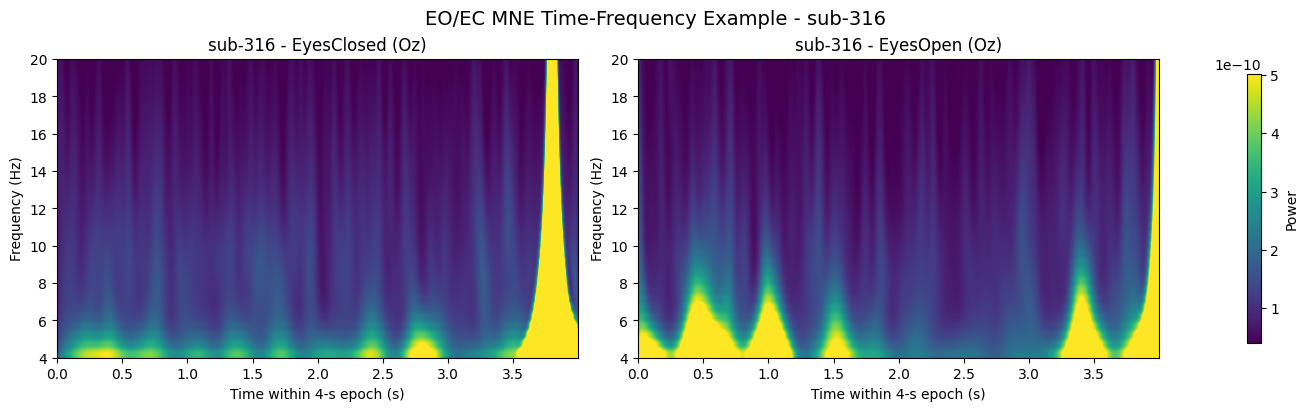


Candidate 5/20: sub-534


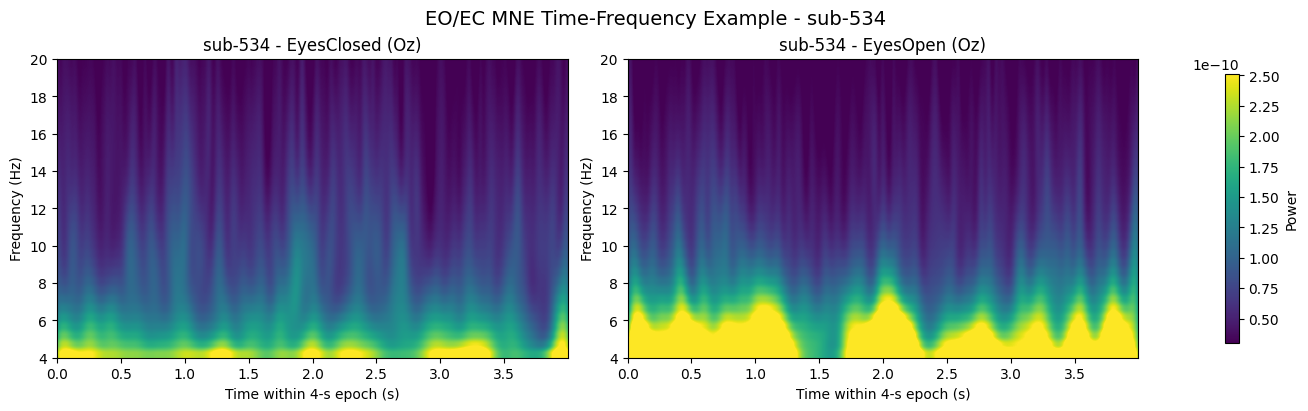


Candidate 6/20: sub-602


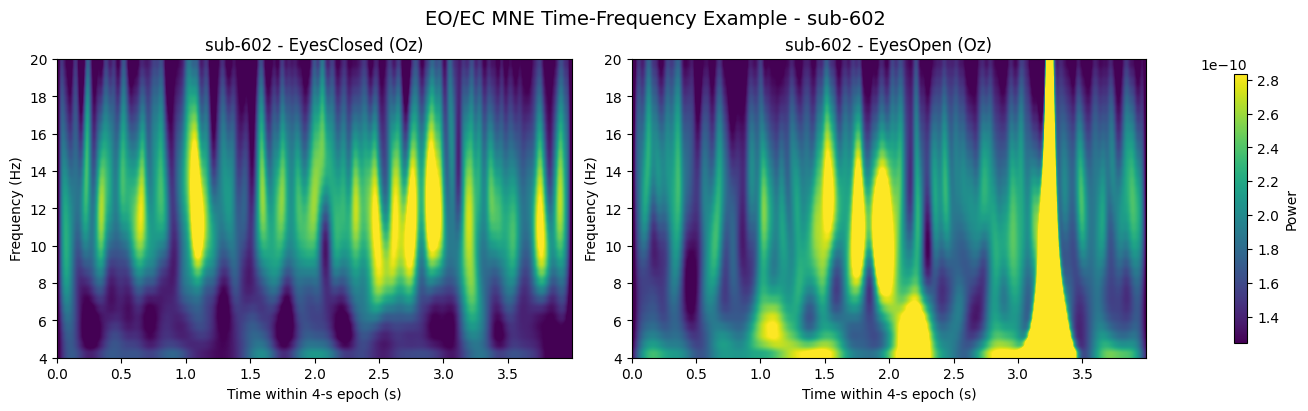


Candidate 7/20: sub-455


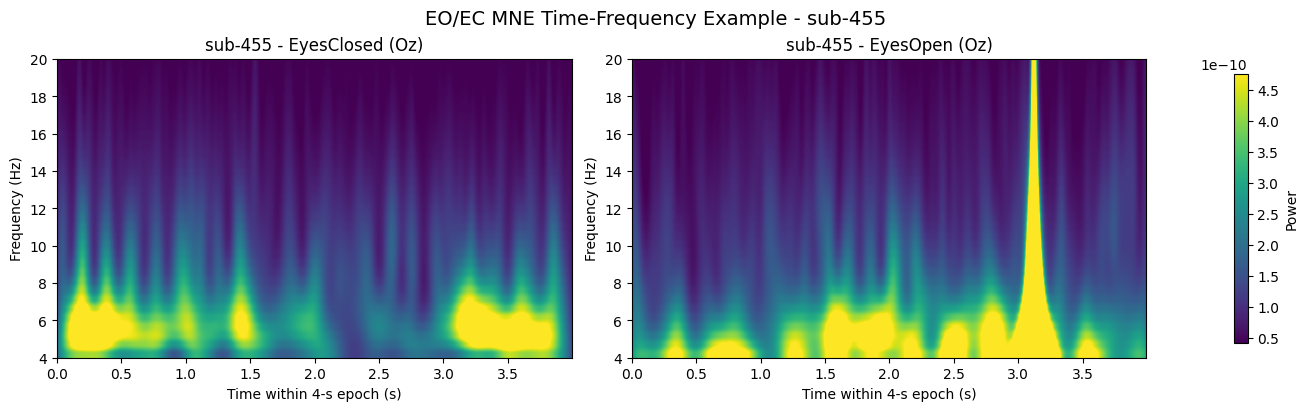


Candidate 8/20: sub-412


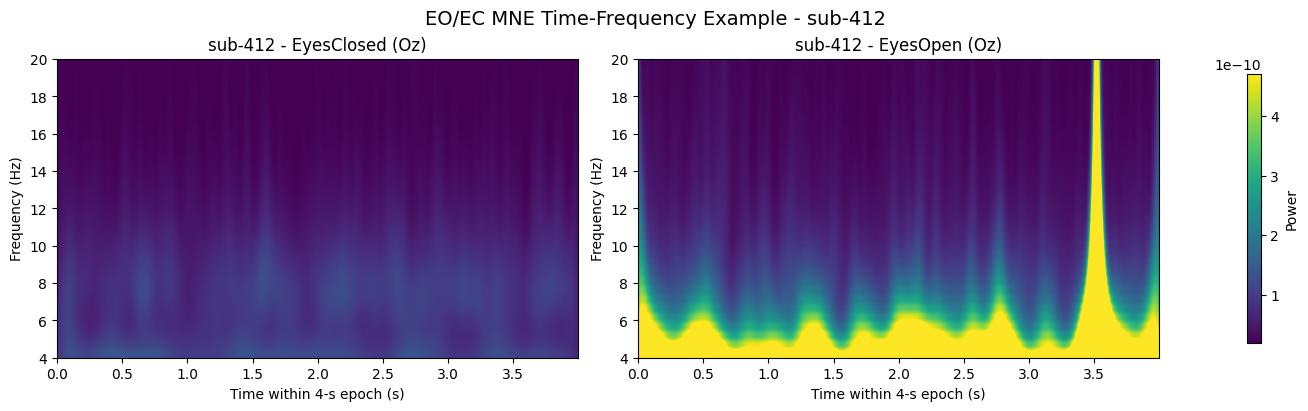


Candidate 9/20: sub-427


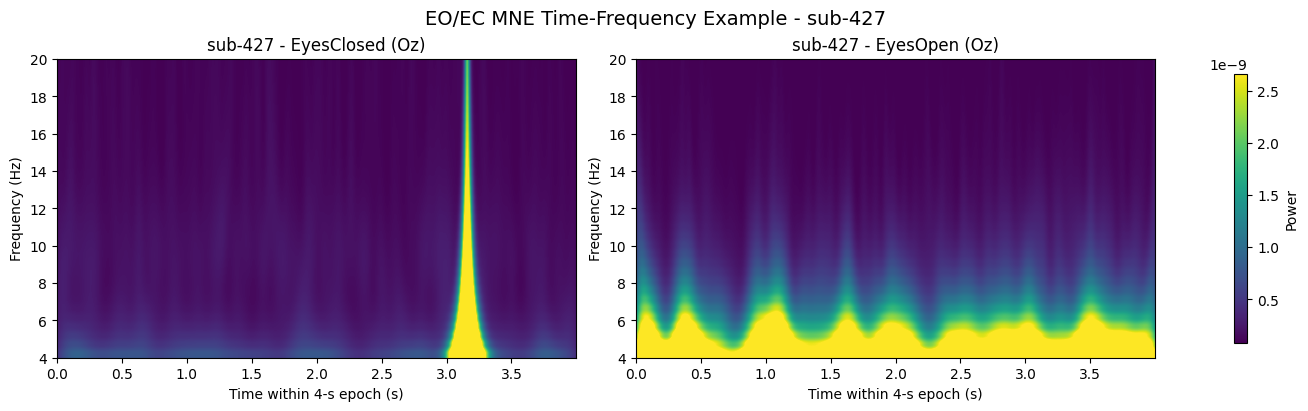


Candidate 10/20: sub-377


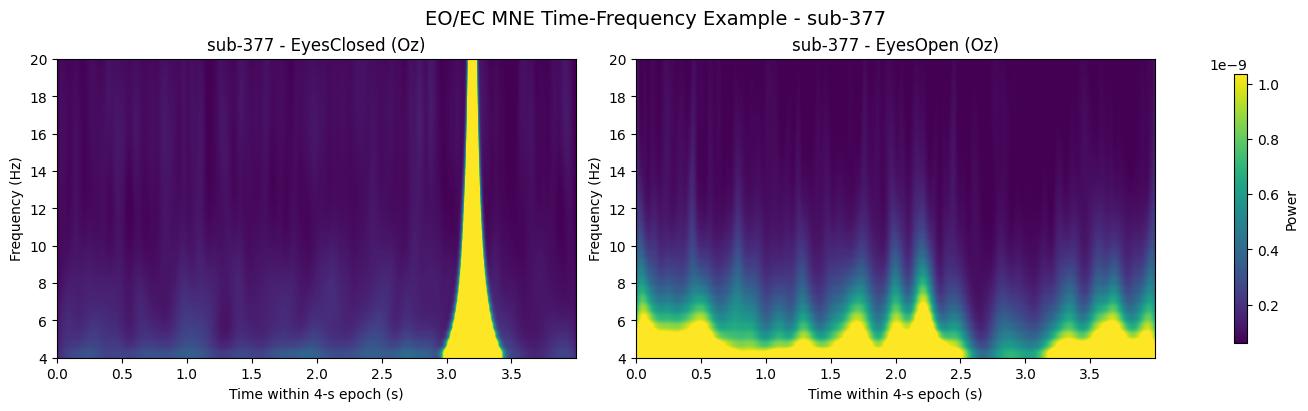


Candidate 11/20: sub-260


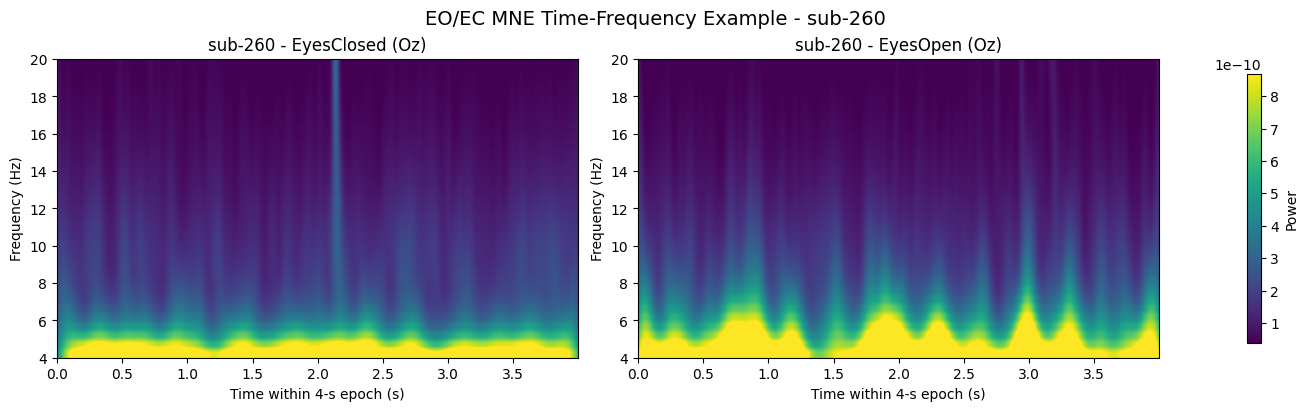


Candidate 12/20: sub-538


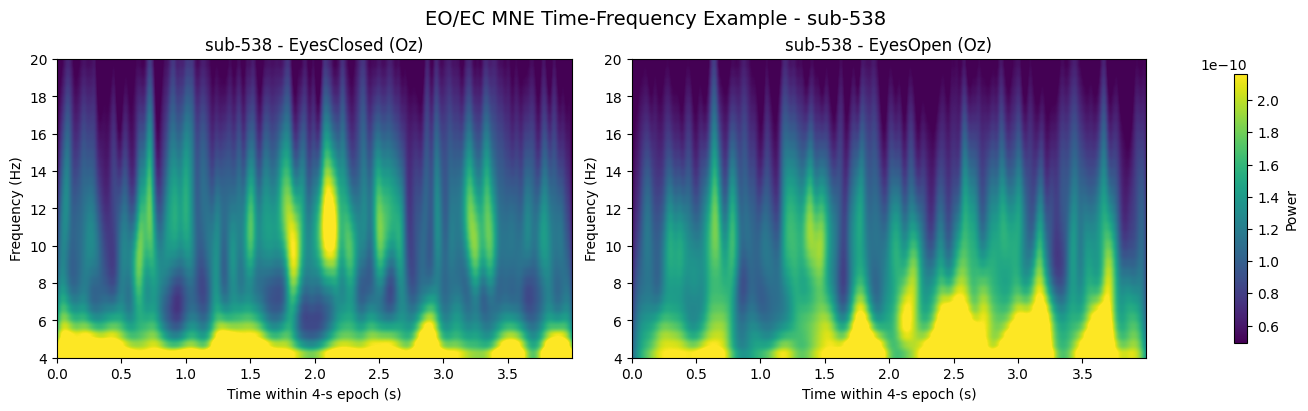


Candidate 13/20: sub-030


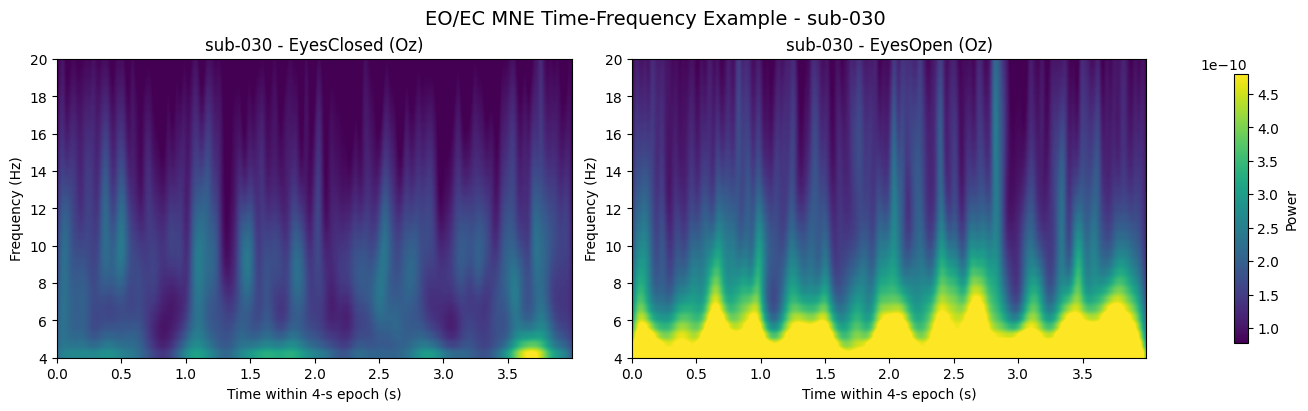


Candidate 14/20: sub-158


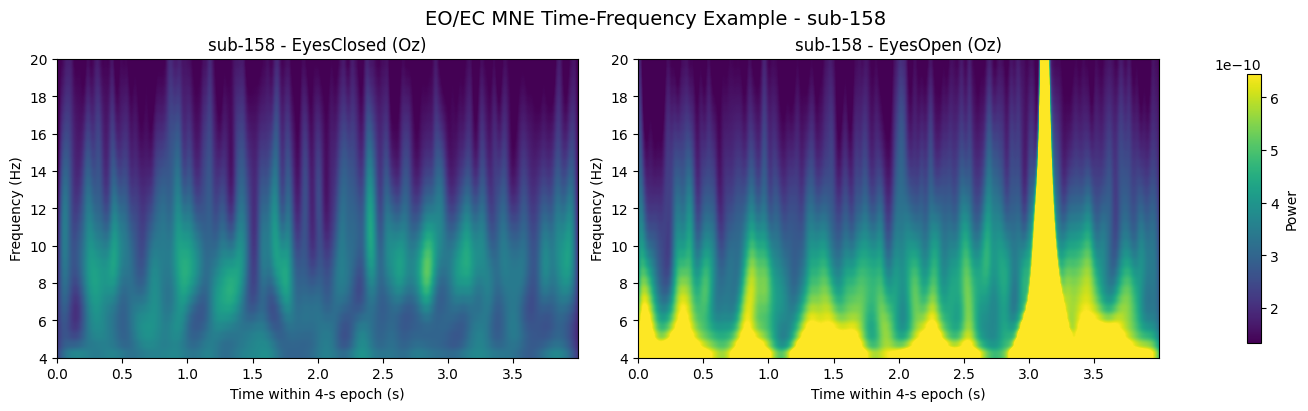


Candidate 15/20: sub-228


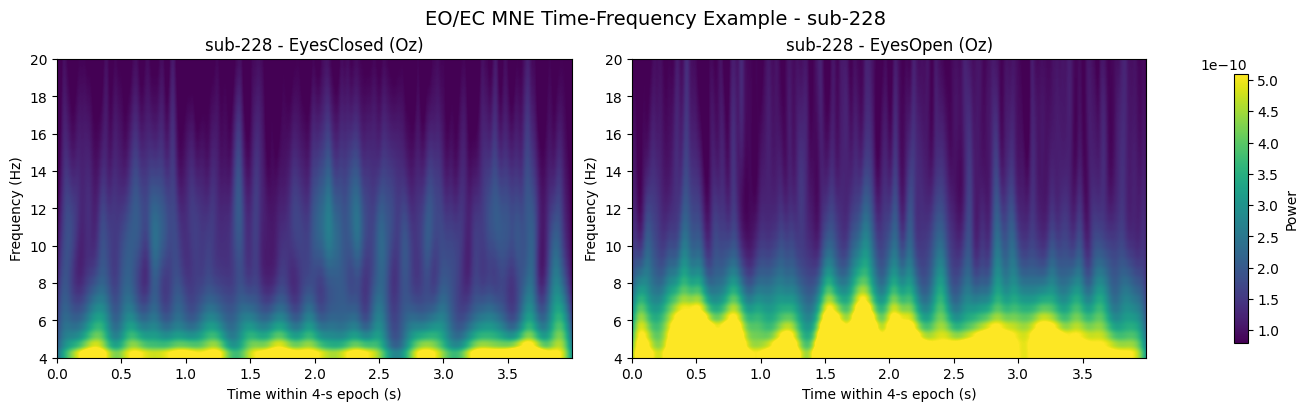


Candidate 16/20: sub-346


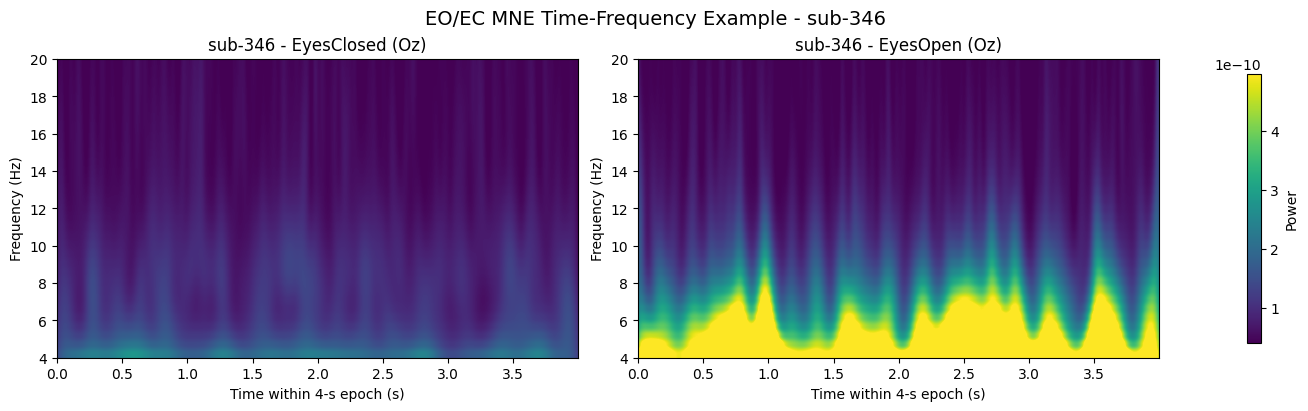


Candidate 17/20: sub-363


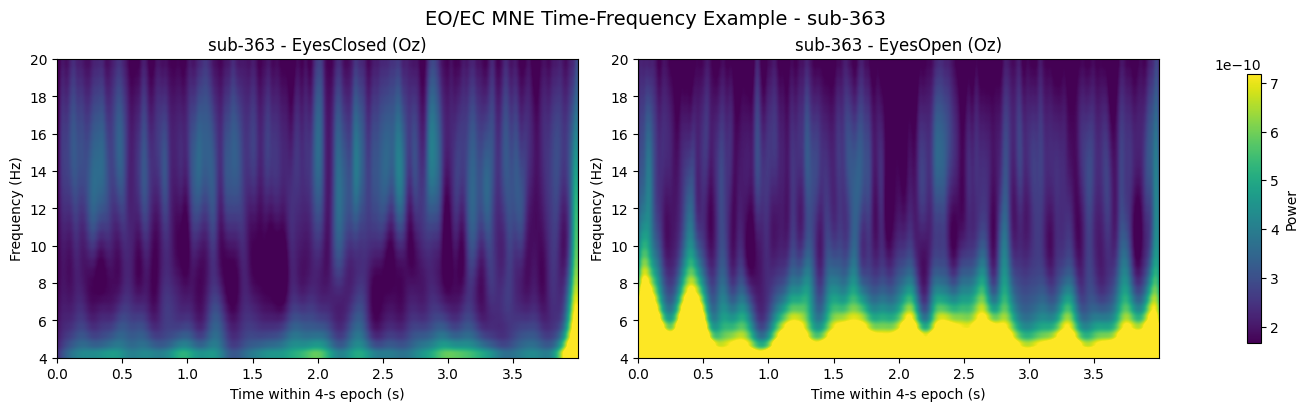


Candidate 18/20: sub-056


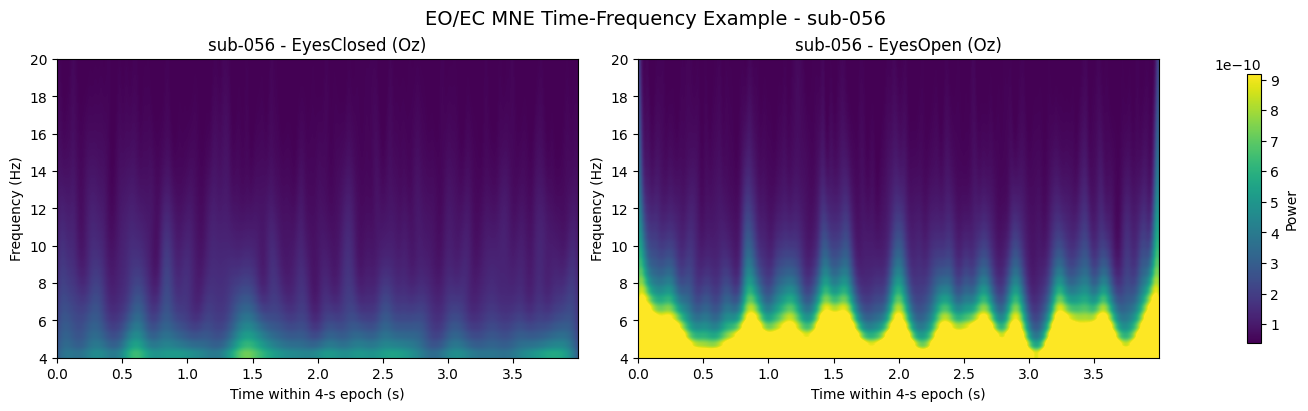


Candidate 19/20: sub-345


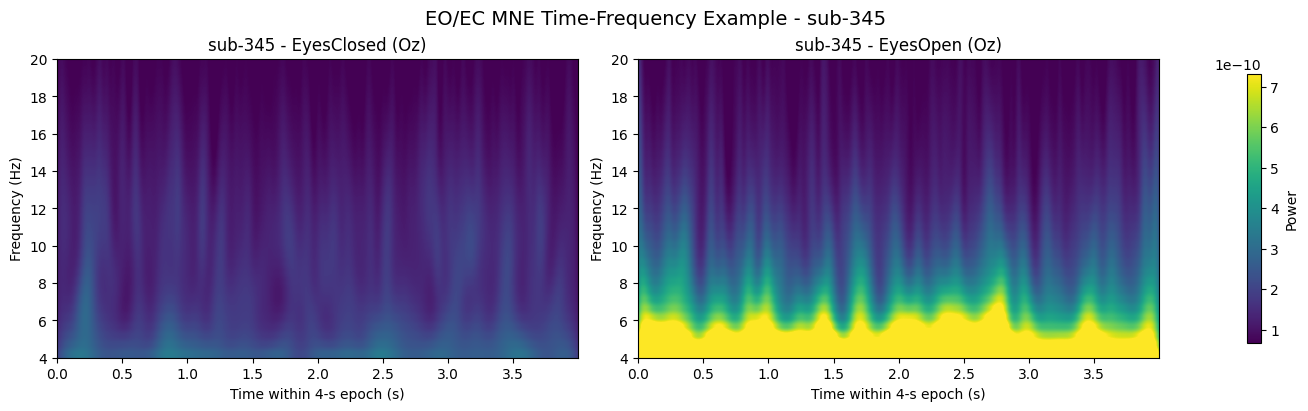


Candidate 20/20: sub-480


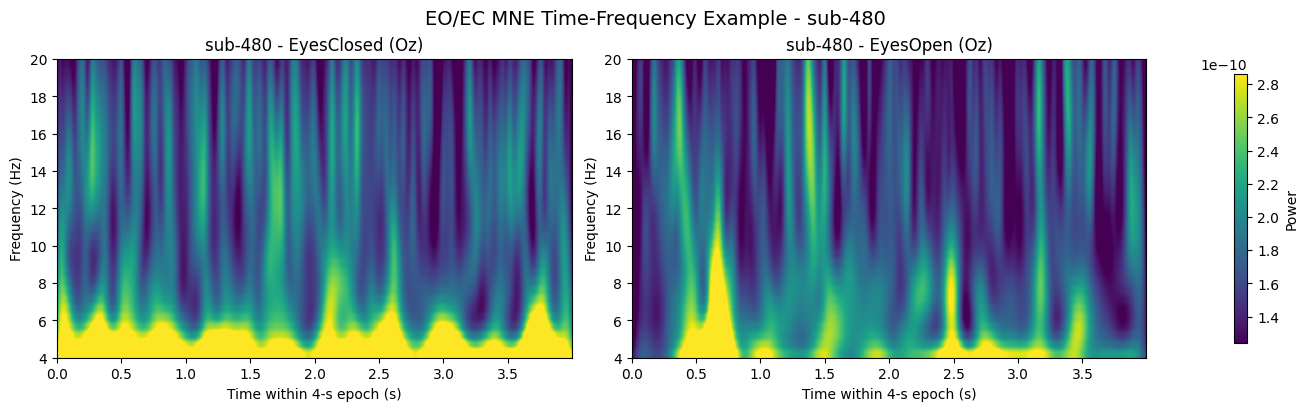

In [82]:
# Plot all candidate small/moderate EO/EC examples

for i, participant_id in enumerate(candidate_small["participant_id"], start=1):
    print(f"\nCandidate {i}/{len(candidate_small)}: {participant_id}")
    
    plot_ec_eo_mne_spectrogram(
        participant_id,
        channel="Oz",
        fmin=4,
        fmax=20
    )

In [83]:
def check_subject_files(participant_id):
    ec_file, eo_file = get_subject_files(participant_id)

    print("Participant:", participant_id)
    print("\nEyesClosed file:")
    print(ec_file)

    print("\nEyesOpen file:")
    print(eo_file)

    assert "EyesClosed" in ec_file, "WARNING: EC file path does not contain EyesClosed"
    assert "EyesOpen" in eo_file, "WARNING: EO file path does not contain EyesOpen"

    print("\nFile labels look correct.")

check_subject_files("sub-102")
check_subject_files("sub-100")
check_subject_files("sub-602")

Participant: sub-102

EyesClosed file:
C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-102\ses-1\eeg\sub-102_ses-1_task-EyesClosed_acq-pre_eeg.edf

EyesOpen file:
C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-102\ses-1\eeg\sub-102_ses-1_task-EyesOpen_acq-pre_eeg.edf

File labels look correct.
Participant: sub-100

EyesClosed file:
C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-100\ses-1\eeg\sub-100_ses-1_task-EyesClosed_acq-pre_eeg.edf

EyesOpen file:
C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-100\ses-1\eeg\sub-100_ses-1_task-EyesOpen_acq-pre_eeg.edf

File labels look correct.
Participant: sub-602

EyesClosed file:
C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-602\ses-1\eeg\sub-602_ses-1_task-EyesClosed_acq-pre_eeg.edf

EyesOpen file:
C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-602\ses-1\eeg\sub-602_ses-1_task-EyesOpen_acq-pre_eeg.edf

File labels look correct.


In [84]:
display(
    features[
        features["participant_id"].isin(["sub-102", "sub-100", "sub-602"])
    ][["participant_id", "condition", "alpha_power_8_12"]]
)

,participant_id,condition,alpha_power_8_12
198,sub-100,EyesClosed,-11.564407
199,sub-100,EyesOpen,-11.660480
202,sub-102,EyesClosed,-10.039994
203,sub-102,EyesOpen,-11.795987
1202,sub-602,EyesClosed,-11.350576
1203,sub-602,EyesOpen,-11.430029
